This example is from:
* https://towardsdatascience.com/transfer-learning-with-vgg16-and-keras-50ea161580b4
* https://github.com/gabrielcassimiro17/object-detection/blob/main/transfer_learning.ipynb

## Imports and loading data

In [2]:
import tensorflow as tf
import numpy as np

In [5]:
import tensorflow_datasets as tfds
from tensorflow.keras.utils import to_categorical

(train_ds, train_labels), (test_ds, test_labels) = tfds.load(
    "tf_flowers",
    split=["train[:70%]", "train[:30%]"],
    batch_size=-1,
    as_supervised=True,  # Include labels
)

KeyError: "Trying to access `splits['train[:70%]']` but `splits` is empty. This likely indicates the dataset has not been generated yet."

In [ ]:
train_ds.shape

TensorShape([2569, 442, 1024, 3])

## Preprocessing data

In [ ]:
size = (150, 150)

train_ds = tf.image.resize(train_ds, (150, 150))
test_ds = tf.image.resize(test_ds, (150, 150))

train_labels = to_categorical(train_labels, num_classes=5)
test_labels = to_categorical(test_labels, num_classes=5)

In [ ]:
train_ds.shape

TensorShape([2569, 150, 150, 3])

## Loading VGG16 model

In [ ]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

train_ds = preprocess_input(train_ds) 
test_ds = preprocess_input(test_ds)

base_model = VGG16(weights="imagenet", include_top=False, input_shape=train_ds[0].shape)
base_model.trainable = False


In [10]:
base_model.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 150, 150, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 150, 150, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 75, 75, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 75, 75, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 75, 75, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 37, 37, 128)       0     

## Adding Layers

In [11]:
from tensorflow.keras import layers, models

flatten_layer = layers.Flatten()
dense_layer_1 = layers.Dense(50, activation='relu')
dense_layer_2 = layers.Dense(20, activation='relu')
prediction_layer = layers.Dense(5, activation='softmax')



model = models.Sequential([
    base_model,
    flatten_layer,
    dense_layer_1,
    dense_layer_2,
    prediction_layer
])


In [12]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 8192)              0         
                                                                 
 dense (Dense)               (None, 50)                409650    
                                                                 
 dense_1 (Dense)             (None, 20)                1020      
                                                                 
 dense_2 (Dense)             (None, 5)                 105       
                                                                 
Total params: 15,125,463
Trainable params: 410,775
Non-trainable params: 14,714,688
_________________________________________________________________


## Training model

In [13]:
from tensorflow.keras.callbacks import EarlyStopping

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)


es = EarlyStopping(monitor='val_accuracy', mode='max', patience=5,  restore_best_weights=True)

history_Train = model.fit(train_ds, train_labels, epochs=50, validation_split=0.2, batch_size=32, callbacks=[es])

Epoch 1/50
65/65 [==============================] - 21s 127ms/step - loss: 2.0557 - accuracy: 0.3455 - val_loss: 1.4021 - val_accuracy: 0.3969
Epoch 2/50
65/65 [==============================] - 6s 100ms/step - loss: 1.3637 - accuracy: 0.4944 - val_loss: 1.3179 - val_accuracy: 0.5019
Epoch 3/50
65/65 [==============================] - 7s 101ms/step - loss: 1.1092 - accuracy: 0.5864 - val_loss: 1.2436 - val_accuracy: 0.5117
Epoch 4/50
65/65 [==============================] - 7s 101ms/step - loss: 0.8844 - accuracy: 0.6487 - val_loss: 1.2214 - val_accuracy: 0.5486
Epoch 5/50
65/65 [==============================] - 7s 102ms/step - loss: 0.7511 - accuracy: 0.7007 - val_loss: 1.3335 - val_accuracy: 0.5992
Epoch 6/50
65/65 [==============================] - 7s 102ms/step - loss: 0.5911 - accuracy: 0.7611 - val_loss: 1.2393 - val_accuracy: 0.6012
Epoch 7/50
65/65 [==============================] - 7s 103ms/step - loss: 0.5153 - accuracy: 0.7854 - val_loss: 1.5227 - val_accuracy: 0.6128
Epoch

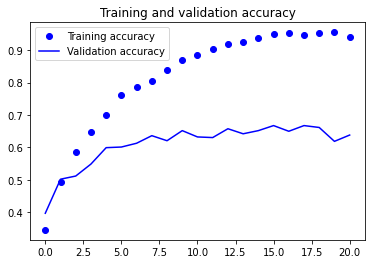

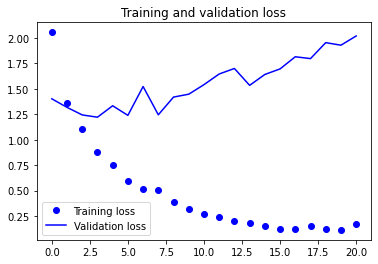

In [14]:
import matplotlib.pyplot as plt
%matplotlib inline

accuracy = history_Train.history['accuracy']
val_accuracy = history_Train.history['val_accuracy']
loss = history_Train.history['loss']
val_loss = history_Train.history['val_loss']
epochs = range(len(accuracy))
plt.plot(epochs, accuracy, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [15]:
model.evaluate(test_ds, test_labels)

35/35 [==============================] - 4s 116ms/step - loss: 0.1249 - accuracy: 0.9491


[0.12487258017063141, 0.9491371512413025]

## Hand Made Model

In [ ]:
from tensorflow.keras import Sequential, layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers.experimental.preprocessing import Rescaling


hand_made_model = Sequential()
hand_made_model.add(Rescaling(1./255, input_shape=(150,150,3)))

hand_made_model.add(layers.Conv2D(16, kernel_size=10, activation='relu'))
hand_made_model.add(layers.MaxPooling2D(3))

hand_made_model.add(layers.Conv2D(32, kernel_size=8, activation="relu"))
hand_made_model.add(layers.MaxPooling2D(2))

hand_made_model.add(layers.Conv2D(32, kernel_size=6, activation="relu"))
hand_made_model.add(layers.MaxPooling2D(2))

hand_made_model.add(layers.Flatten())
hand_made_model.add(layers.Dense(50, activation='relu'))
hand_made_model.add(layers.Dense(20, activation='relu'))
hand_made_model.add(layers.Dense(5, activation='softmax'))


hand_made_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)


es = EarlyStopping(monitor='val_accuracy', mode='max', patience=5,  restore_best_weights=True)

history_Train_hm = hand_made_model.fit(train_ds, train_labels, epochs=50, validation_split=0.2, batch_size=32, callbacks=[es])

Epoch 1/50
65/65 [==============================] - 2s 25ms/step - loss: 1.5472 - accuracy: 0.2686 - val_loss: 1.4965 - val_accuracy: 0.2938
Epoch 2/50
65/65 [==============================] - 1s 20ms/step - loss: 1.3737 - accuracy: 0.3616 - val_loss: 1.2503 - val_accuracy: 0.4572
Epoch 3/50
65/65 [==============================] - 1s 20ms/step - loss: 1.2613 - accuracy: 0.4365 - val_loss: 1.2233 - val_accuracy: 0.4961
Epoch 4/50
65/65 [==============================] - 1s 20ms/step - loss: 1.1856 - accuracy: 0.4783 - val_loss: 1.2105 - val_accuracy: 0.4844
Epoch 5/50
65/65 [==============================] - 1s 20ms/step - loss: 1.1139 - accuracy: 0.5343 - val_loss: 1.2109 - val_accuracy: 0.4630
Epoch 6/50
65/65 [==============================] - 1s 20ms/step - loss: 1.0389 - accuracy: 0.5713 - val_loss: 1.1590 - val_accuracy: 0.5156
Epoch 7/50
65/65 [==============================] - 1s 20ms/step - loss: 0.9413 - accuracy: 0.6044 - val_loss: 1.1676 - val_accuracy: 0.5370
Epoch 8/50
65

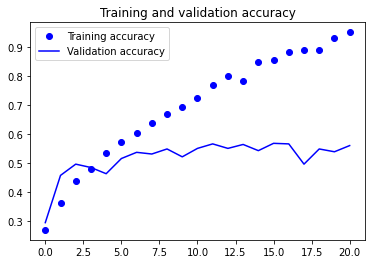

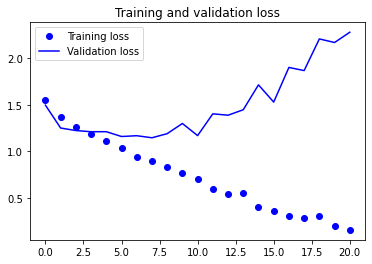

In [ ]:
accuracy = history_Train_hm.history['accuracy']
val_accuracy = history_Train_hm.history['val_accuracy']
loss = history_Train_hm.history['loss']
val_loss = history_Train_hm.history['val_loss']
epochs = range(len(accuracy))
plt.plot(epochs, accuracy, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [ ]:
hand_made_model.evaluate(test_ds, test_labels)

35/35 [==============================] - 0s 11ms/step - loss: 0.3158 - accuracy: 0.8874


[0.3157747983932495, 0.8873751163482666]